# Model Evaluation
This notebook evaluates the trained model on the test set and generates performance metrics.

In [29]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib
import matplotlib.pyplot as plt
%run 01_preprocessing.ipynb
%run 02_model_training.ipynb

## Generate Summary Metric on Test Set

In [30]:
# function to display summary metrics
def summary_metrics(model, X_test_t, y_test_t):
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).argmax(dim=1)

    print("Classification Report:")
    print(classification_report(y_test_t, preds))

    print("Confusion Matrix:")
    cm = confusion_matrix(y_test_t, preds)
    print(cm)

    # overall accuracy
    accuracy = (preds == y_test_t).float().mean().item()
    print(f"\nOverall Test Accuracy: {accuracy:.4f}")
    print(f"Correct Predictions: {(preds == y_test_t).sum().item()}/{len(y_test_t)}")

Epoch 000 | Train Loss: 1.1350 | Val Loss: 1.0802 | Val Acc: 0.5696
Epoch 005 | Train Loss: 0.7687 | Val Loss: 0.9413 | Val Acc: 0.6643
Epoch 010 | Train Loss: 0.6099 | Val Loss: 0.7406 | Val Acc: 0.7325
Epoch 015 | Train Loss: 0.5195 | Val Loss: 0.5906 | Val Acc: 0.7823
Epoch 020 | Train Loss: 0.4574 | Val Loss: 0.4943 | Val Acc: 0.8174
Epoch 025 | Train Loss: 0.4095 | Val Loss: 0.4280 | Val Acc: 0.8431
Epoch 030 | Train Loss: 0.3716 | Val Loss: 0.3756 | Val Acc: 0.8649
Epoch 035 | Train Loss: 0.3420 | Val Loss: 0.3305 | Val Acc: 0.8833
Epoch 040 | Train Loss: 0.3163 | Val Loss: 0.2919 | Val Acc: 0.8962
Epoch 045 | Train Loss: 0.2947 | Val Loss: 0.2610 | Val Acc: 0.9053
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      8911
           1       0.90      0.86      0.88      6948
           2       0.73      1.00      0.85      1970

    accuracy                           0.91     17829
   macro avg       0.87  

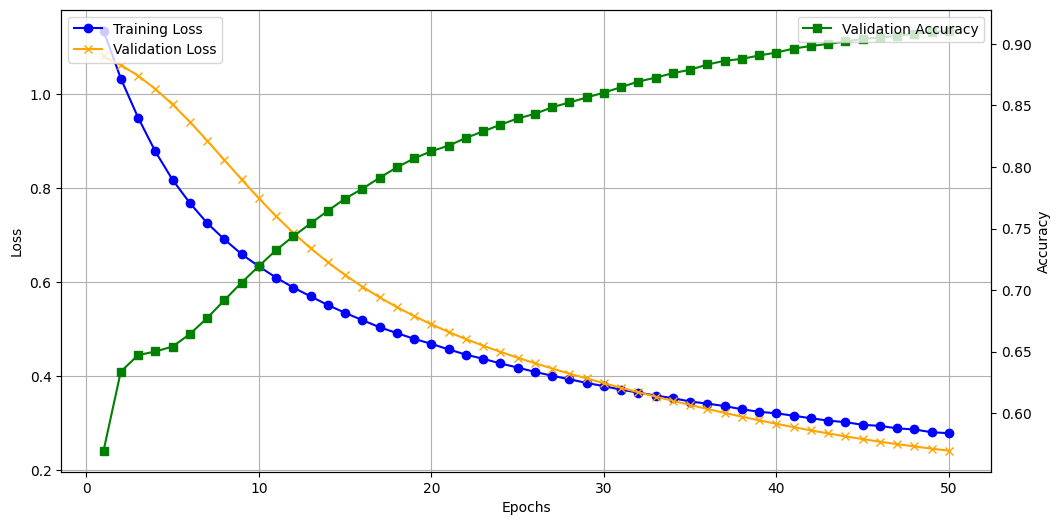

In [31]:
# main function to run the model training and evaluation
def main(data_src="final_dataset.csv"):
    model, X_test_t, y_test_t, train_losses, val_losses, val_accs = risk_classifier(data_src)
    summary_metrics(model, X_test_t, y_test_t)

    epochs_range = range(1, len(train_losses) + 1)
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(epochs_range, train_losses, label='Training Loss', marker='o', color='blue')
    ax1.plot(epochs_range, val_losses, label='Validation Loss', marker='x', color='orange')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid(True)
    ax1.legend(loc='upper left')

    # Plot validation accuracy on a secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(epochs_range, val_accs, label='Validation Accuracy', marker='s', color='green')
    ax2.set_ylabel('Accuracy')
    ax2.legend(loc='upper right')
main()